<ipython-input-51-532397fe5d4c>:10: RuntimeWarning: overflow encountered in double_scalars
  return -k * c + k * (1 + 0.1 *np.sin(0.1 * t))
<ipython-input-51-532397fe5d4c>:26: RuntimeWarning: invalid value encountered in double_scalars
  c_values[i] = c_n + h_val * f(c_n, t_values[i - 1])


Forward h = 0.01 | Number of steps: 2001
Forward h = 0.05 | Number of steps: 400
Forward h = 0.1 | Number of steps: 200

Maximum Stable Step Size (Forward Method): 0.0002 | Step sizes: [0.01, 0.05, 0.1] | Required Steps for Stability: 100000

Forward Euler Stable Steps: 100000 | Total Iterations: 100000

------------Backward Euler Method------------
h = 0.01 | Average Iterations: 1.00199900049975 | Total Evaluations: 2005 | Number of Time Steps: 2001 | Min Value: 0.0
h = 0.05 | Average Iterations: 1.8025 | Total Evaluations: 721 | Number of Time Steps: 400 | Min Value: 0.0
h = 0.1 | Average Iterations: 1.965 | Total Evaluations: 393 | Number of Time Steps: 200 | Min Value: 0.0


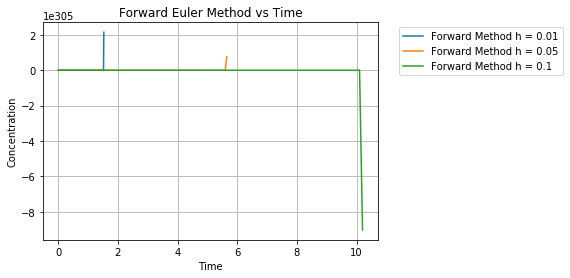

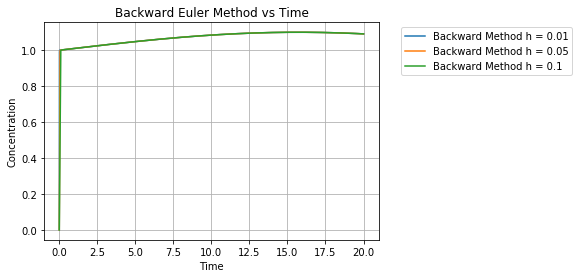

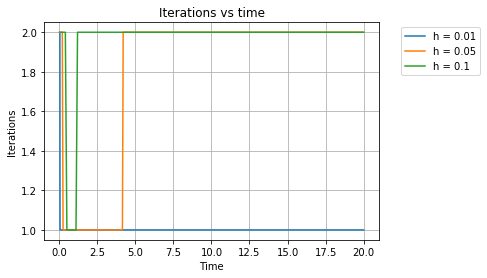

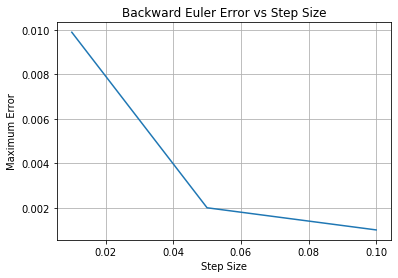

In [51]:
import numpy as np
import matplotlib.pyplot as plt

h_list = [0.01, 0.05, 0.1]
t_start = 0    
t_end = 20
k = 10 ** 4

def f(c, t):
    return -k * c + k * (1 + 0.1 *np.sin(0.1 * t))

def real_solution(t): #chatgpt helped me find the real solution for the function
    term1 = 0.1 * k**2 / (k**2 + 0.1**2)
    term2 = -0.1 * k * 0.1 / (k**2 + 0.1**2)
    term3 = -(1 + term2)
    return 1 + term1 * np.sin(0.1 * t) + term2 * np.cos(0.1 * t) + term3 * np.exp(-k * t)


def euler_forward(h_val, t_start, t_end): #explicit method that displays instability for stiff ODEs
    t_values = np.arange(t_start, t_end + h_val, h_val)
    c_values = np.zeros(len(t_values))
    c_values[0] = 0 #initial values

    for i in range(1, len(t_values)):
        c_n = c_values[i - 1]
        c_values[i] = c_n + h_val * f(c_n, t_values[i - 1])
    return t_values, c_values

def euler_backward_newton(f, t_start, t_end, h_val, tol = 1e-6, max_iteration = 15): #implicit method to contrast with explicit method
    t_values = np.arange(t_start, t_end + h_val, h_val)
    y_values = np.zeros_like(t_values)
    y_values[0] = 0
    iteration_counts = []
    
    for j in range(1, len(t_values)):
        t_next = t_values[j]
        y_prev = y_values[j - 1]
        y_guess = y_prev + h_val * f(y_prev, t_values[j - 1]) #initial guess
        converge = False

        for z in range(max_iteration):
            g = y_guess - y_prev - h_val * f(y_guess, t_next)         # residual function
            g_prime = 1 + h_val * k
            y_next = y_guess - (g / g_prime) #updating newton-raphson
            
            if abs(y_next - y_guess) < tol: #check convergence
                converge = True
                iteration_counts.append(z + 1)
                y_guess = y_next
                break
            y_guess = y_next
            
        if converge is False:
            print(f'Newton did not converge at t = {t_next}')
            iteration_counts.append(max_iteration)
        y_values[j] = y_guess
            
    return t_values, y_values, iteration_counts

plt.figure()
for step in h_list: 
    ef_t, ef_y = euler_forward(step, t_start, t_end)    
    plt.plot(ef_t, ef_y, label = f'Forward Method h = {step}')
    print(f'Forward h = {step} | Number of steps: {len(ef_t) - 1}')
    
max_stable = 2 / k #chatgpt helped me with solving the required steps/step cost
print(f'\nMaximum Stable Step Size (Forward Method): {max_stable} | Step sizes: {h_list} | Required Steps for Stability: {int((t_end - t_start) / max_stable)}\n')

forward_steps = int((t_end - t_start) / max_stable)
print(f'Forward Euler Stable Steps: {forward_steps} | Total Iterations: {forward_steps}\n')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Forward Euler Method vs Time')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.grid(True)

plt.figure()

for steps in h_list: 
    eb_t, eb_y, iterations = euler_backward_newton(f, t_start, t_end, steps)
    plt.plot(eb_t, eb_y, label = f'Backward Method h = {steps}')
    
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Backward Euler Method vs Time')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.grid(True)
print('------------Backward Euler Method------------')
plt.figure()
for steps in h_list: 
    eb_t, eb_y, iterations = euler_backward_newton(f, t_start, t_end, steps) 
    plt.plot(eb_t[1:], iterations, label = f'h = {steps}')    
    print(f'h = {steps} | Average Iterations: {np.mean(iterations)} | Total Evaluations: {sum(iterations)} | Number of Time Steps: {len(eb_t) - 1} | Min Value: {np.min(eb_y)}')     

plt.xlabel('Time')
plt.ylabel('Iterations')
plt.title(f'Iterations vs time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

err = [] 

for steps in h_list:
    eb_t, eb_y, iterations = euler_backward_newton(f, t_start, t_end, steps)
    real_y = real_solution(eb_t)

    max_error = np.max(np.abs(eb_y - real_y))
    err.append(max_error) #compute maximum error for each step size
    
plt.figure()
plt.plot(h_list, err)
plt.xlabel('Step Size')
plt.ylabel('Maximum Error')
plt.title('Backward Euler Error vs Step Size')
plt.grid(True)
plt.show()

In [ ]:
'''''
For my simulation I chose the chemical reaction with fast kinetics. The first order differential equation used for this is dC/dt
= -k(C - Ceq). Here, k is the reaction rate (10^4), C is the initial condition (0), and Ceq is the slowly varying equilibrium 
(1 + 0.1*sin(0.1*t)). The reaction is stiff due to the fast reaction rate (10^4) paired with the slow varying equilibrium. The 
Forward Euler method becomes unstable for the sizes used. When we calculate the size needed for stability (0.0002) and the steps
needed (100000), it shows how impractical it is to use the Forward method. Due to this, implicit methods are necessary to use. 
The residual function is g(yn+1​) = yn+1 ​− yn ​− hf * (tn+1​,yn+1​) = 0. The derivative of g is g′ = 1+ h*k. The derivative is
constant which makes Newton-Raphson efficient. Due to this it converges in a few iterations. The Forward method becomes unstable
as step size increases, however, the Backward method remains stable. The error also decreases as step size decreases with the 
Backward method. This exemplifies how it does not have the same limitations as the Forward method. Although the computational 
cost per step of the Backward method is greater than the Forward method, it is worth it for the greater stability and efficiency.
This is especially true for stiff systems. For practical and real-world applications, the Backward method should be used. The 
simulation shows us that for stiff problems implicit methods must be used. Explicit methods either fail or become impractical 
when compared with implicit methods; as seen in the Forward vs Backward methods. For non-stiff problems explicit methods should 
be used since they require less computational cost. One thing I learned is that stability is not always synonymous with accuracy.
One challenge I encountered was trying to solve and code the exact solution to our ODE. 

'''''